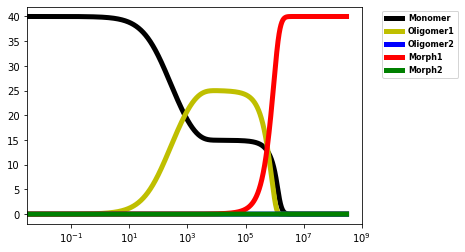

In [4]:
###### we consider a special case in which large oligomer2 will have lower stability and zero conformation conversion barrier.

###### Figure 6B,top

import matplotlib.pyplot as plt
import numpy as np
import math
import gc
import pandas as pd
import matplotlib.cm as cm
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
plt.close('all')

for G in [5*10**(-4)]:        ## Tune the parameter of interest
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf1, 5Nf2, 6Phi_CR1, 7Phi_CR2, 8Kf1-p;1st-pathway, 9Kf1-;1st-pathway, 10Kf2-p;2nd-pathway, 11Kf2-;2nd-pathway, 12Kfrag, 13G1, 14G2] 
    p0=   [0,     0,    0,       0, 4, 15, 0.01, 0.01, 1*10**(-4), 5*10**(-8), G, 5*10**(-8), 0, 6, 0 ]     #### Free parameters in our model 
    yyy=[0.6,0.8,1,2,3,4,6,8,10,15,20,30,40,50,60,80,100,149,200,300,400]                                   #### Discrete point initial peptide concentrations 
    yy = [x / p0[6] for x in yyy]                                                                           #### Discrete point initial peptide concentrations 
    n= len(yyy)                                                                                             #### Total discrete point concentration
    phi_su1=p0[8]*p0[6]/p0[9]
    phi_su2=p0[10]*p0[7]/p0[11]
    
    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u): 
        global switch
        du = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]         # Introduce all states in our model
        
        #### Aproximate nf1+9 and truncate the high order dependency
        CC1=0;CC2=0;FF1=0;FF2=0;
        for i in range (10,27):
            CC1 += u[i]
            FF1 += (p[4]+ (i-9))*u[i]
        for i in range (27,44):
            CC2 += u[i]
            FF2 += (p[5]+ (i-26))*u[i]
        #### Aproximate nf1+9 and truncate the high order dependency        
        if t>0:
            if u[25]<= 0:
                n1plus1= 0
            else:
                if u[0]>= 1:
                    n1plus1= u[26]*u[26]/u[25]
                else :
                    CC3= u[5] -  CC1                   
                    FF3= u[6] -  FF1                   
                    if CC3 <= 0 or FF3 < 0  or FF3/CC3 <= p[4]+ 17:
                        n1plus1=0
                        switch=1
                    else:
                        n1plus1= CC3/((FF3/CC3-(p[4]+17)))                   
        else:
            n1plus1= 0 
            
        #### Aproximate nf2+9 and truncate the high order dependency   
        if t>0:
            if u[42]<= 0:
                n2plus1= 0
            else:
                if u[0]>= p[7]/p[6]:
                    n2plus1= u[43]*u[43]/u[42]
                else:
                    CC4= u[8] -  CC2        
                    FF4= u[9] -  FF2        
                    if CC4 <=0 or FF4 <= 0 or FF4/CC4 <= p[5]+17:
                        n2plus1=0
                    else:
                        n2plus1= CC4/((FF4/CC4 -(p[5]+17)))
        else:
            n2plus1= 0
         
        ### Define different terms 
        EEE1=  (p[6]/phi_su1)**(p[4]-1)*u[0]**p[4] - u[4];                                   # 1st-pathway oligomer number nucleation  
        EEE2=  p[10]/p[8]*((p[6]/phi_su2)**(p[5]-1)*u[0]**p[5] - u[7]);                      # 2nd-pathway oligomer number nucleation
        EE1=   p[4]*EEE1;                                                                    # 1st-pathway oligomer mass nucleation  
        EE2=   p[5]*EEE2;                                                                    # 2nd-pathway oligomer mass nucleation  
        NNN1=  (p[6]/phi_su1)*(u[0]*u[4] - u[10])*np.exp(-p[13])                             # 1st-pathway oligomer to fibril seed conversion
        NNN2=  p[10]/p[8]*(p[6]/phi_su2)*(u[0]*u[7] - u[27]*p[7]/p[6])*np.exp(-p[14])        # 2nd-pathway oligomer to fibril seed conversion
        NN1=  (p[4]+1)* NNN1                                                                 # fibril mass from 1st-pathway oligomer to fibril seed conversion
        NN2=  (p[5]+1)* NNN2                                                                 # fibril mass from 2nd-pathway oligomer to fibril seed conversion
        GG1= (u[0]-1)*u[5]*(p[6]/phi_su1) +  (p[6]/phi_su1)* u[10];                          # Growth and shrinking of the 1st-pathway fibril  
        GG2=  p[10]/p[8]*((u[0]-p[7]/p[6])*u[8]*(p[6]/phi_su2) + (p[7]/phi_su2)* u[27]);     # Growth and shrinking of the 2nd-pathway fibril 
        
        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2                  
        du[1] = 0      
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 
        du[6] = NN1 + GG1 
        du[7] = EEE2 - NNN2
        du[8] = NNN2 
        du[9] = NN2 + GG2
        #############################################################
        du[10]= (u[0]*u[4]*np.exp(-p[13]) -(u[0] + np.exp(-p[13]))*u[10] + u[11])*p[6]/phi_su1
        du[11]= (u[0]*u[10] -(u[0] + 1)*u[11] + u[12])*p[6]/phi_su1
        du[12]= (u[0]*u[11] -(u[0] + 1)*u[12] + u[13])*p[6]/phi_su1
        du[13]= (u[0]*u[12] -(u[0] + 1)*u[13] + u[14])*p[6]/phi_su1
        du[14]= (u[0]*u[13] -(u[0] + 1)*u[14] + u[15])*p[6]/phi_su1
        du[15]= (u[0]*u[14] -(u[0] + 1)*u[15] + u[16])*p[6]/phi_su1
        du[16]= (u[0]*u[15] -(u[0] + 1)*u[16] + u[17])*p[6]/phi_su1
        du[17]= (u[0]*u[16] -(u[0] + 1)*u[17] + u[18])*p[6]/phi_su1
        du[18]= (u[0]*u[17] -(u[0] + 1)*u[18] + u[19])*p[6]/phi_su1
        du[19]= (u[0]*u[18] -(u[0] + 1)*u[19] + u[20])*p[6]/phi_su1
        du[20]= (u[0]*u[19] -(u[0] + 1)*u[20] + u[21])*p[6]/phi_su1
        du[21]= (u[0]*u[20] -(u[0] + 1)*u[21] + u[22])*p[6]/phi_su1
        du[22]= (u[0]*u[21] -(u[0] + 1)*u[22] + u[23])*p[6]/phi_su1
        du[23]= (u[0]*u[22] -(u[0] + 1)*u[23] + u[24])*p[6]/phi_su1
        du[24]= (u[0]*u[23] -(u[0] + 1)*u[24] + u[25])*p[6]/phi_su1
        du[25]= (u[0]*u[24] -(u[0] + 1)*u[25] + u[26])*p[6]/phi_su1
        du[26]= (u[0]*u[25] -(u[0] + 1)*u[26] + n1plus1)*p[6]/phi_su1
        ##############################################################
        du[27]= p[10]/p[8]*(u[0]*u[7]*np.exp(-p[14]) -(u[0] + p[7]/p[6]*np.exp(-p[14]))*u[27] + p[7]/p[6]*u[28])*p[6]/phi_su2
        du[28]= p[10]/p[8]*(u[0]*u[27] -(u[0] + p[7]/p[6])*u[28] + p[7]/p[6]*u[29])*p[6]/phi_su2
        du[29]= p[10]/p[8]*(u[0]*u[28] -(u[0] + p[7]/p[6])*u[29] + p[7]/p[6]*u[30])*p[6]/phi_su2
        du[30]= p[10]/p[8]*(u[0]*u[29] -(u[0] + p[7]/p[6])*u[30] + p[7]/p[6]*u[31])*p[6]/phi_su2
        du[31]= p[10]/p[8]*(u[0]*u[30] -(u[0] + p[7]/p[6])*u[31] + p[7]/p[6]*u[32])*p[6]/phi_su2
        du[32]= p[10]/p[8]*(u[0]*u[31] -(u[0] + p[7]/p[6])*u[32] + p[7]/p[6]*u[33])*p[6]/phi_su2
        du[33]= p[10]/p[8]*(u[0]*u[32] -(u[0] + p[7]/p[6])*u[33] + p[7]/p[6]*u[34])*p[6]/phi_su2
        du[34]= p[10]/p[8]*(u[0]*u[33] -(u[0] + p[7]/p[6])*u[34] + p[7]/p[6]*u[35])*p[6]/phi_su2
        du[35]= p[10]/p[8]*(u[0]*u[34] -(u[0] + p[7]/p[6])*u[35] + p[7]/p[6]*u[36])*p[6]/phi_su2
        du[36]= p[10]/p[8]*(u[0]*u[35] -(u[0] + p[7]/p[6])*u[36] + p[7]/p[6]*u[37])*p[6]/phi_su2
        du[37]= p[10]/p[8]*(u[0]*u[36] -(u[0] + p[7]/p[6])*u[37] + p[7]/p[6]*u[38])*p[6]/phi_su2
        du[38]= p[10]/p[8]*(u[0]*u[37] -(u[0] + p[7]/p[6])*u[38] + p[7]/p[6]*u[39])*p[6]/phi_su2
        du[39]= p[10]/p[8]*(u[0]*u[38] -(u[0] + p[7]/p[6])*u[39] + p[7]/p[6]*u[40])*p[6]/phi_su2
        du[40]= p[10]/p[8]*(u[0]*u[39] -(u[0] + p[7]/p[6])*u[40] + p[7]/p[6]*u[41])*p[6]/phi_su2
        du[41]= p[10]/p[8]*(u[0]*u[40] -(u[0] + p[7]/p[6])*u[41] + p[7]/p[6]*u[42])*p[6]/phi_su2
        du[42]= p[10]/p[8]*(u[0]*u[41] -(u[0] + p[7]/p[6])*u[42] + p[7]/p[6]*u[43])*p[6]/phi_su2
        du[43]= p[10]/p[8]*(u[0]*u[42] -(u[0] + p[7]/p[6])*u[43] + p[7]/p[6]*n2plus1)*p[6]/phi_su2
            
        if switch == 1 and u[0]< p[7]:
            CC5= u[5] -  u[10]                 
            FF5= u[6] -  (p[4]+1)*u[10]   
            u[11]= CC5/(FF5/CC5-p[4]-1)
            du[10]= (u[0]*u[4]*np.exp(-p[13]) -(u[0] + np.exp(-p[13]))*u[10] + u[11])*p[6]/phi_su1
            for i in range(11,27):
                du[i]=0 
            for i in range(11,26):
                u[i+1]=0
            
        return du
    
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x21=3*10**9;x20=15*10**8;x19=6*10**8;x18=1*10**8;x17=5*10**8; x16=3*10**8; x16a=8*10**7; x15=1*10**9; x14=3*10**8; x13=3*10**8;
    tend0 = [x21,x20,x19,x18,x17,x16,x16a,x15,x15,x15,x14,x14,x14,x14,x14,x13,x13,x13,x13,x13,x13,x13]
    tend = [y*p0[8] for y in tend0]  
    
    #########################################################################
    for i in [12]: 
        switch=0
        y0 = [yy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]                           ## Introduce the initial condition
        y00 = [yyy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]                         
        p  = p0  ## parameters in our model
        
        #### solve rate-mass equations using solve_ivp
        if y0[0] <= 200:
            tspan1 = (0, 1)
            t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
            #t_eval1 = np.logspace(np.log10(tspan1[0]), np.log10(tspan1[1]), 1000000)
            sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF',  atol=1e-12, rtol=1e-12)
            
            tspan2 = (tspan1[1], tend[i])
            t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
            sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], method='BDF',  atol=1e-12, rtol=1e-12)
            
        elif y0[0] <= 400:
            tspan1 = (0, 100)
            t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
            #t_eval1 = np.logspace(np.log10(tspan1[0]), np.log10(tspan1[1]), 1000000)
            sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF',  atol=1e-12, rtol=1e-12)
            
            tspan2 = (tspan1[1], tend[i])
            t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
            sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], method='BDF',  atol=1e-50, rtol=1e-50)
            
        elif y0[0] <= 600:
            tspan1 = (0, 1)
            t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
            #t_eval1 = np.logspace(np.log10(tspan1[0]), np.log10(tspan1[1]), 1000000)
            sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF',  atol=1e-12, rtol=1e-12)
            
            tspan2 = (tspan1[1], tend[i])
            t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
            sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], method='BDF',  atol=1e-40, rtol=1e-40)
            
        elif y0[0] <= 6000:
            tspan1 = (0, 1)
            t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
            #t_eval1 = np.logspace(np.log10(tspan1[0]), np.log10(tspan1[1]), 1000000)
            sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF',  atol=1e-12, rtol=1e-12)
            
            tspan2 = (tspan1[1], tend[i])
            t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
            sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], method='BDF',  atol=1e-12, rtol=1e-12)
          
        elif y0[0] <= 20000:
            tspan1 = (0, 0.00001)
            t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
            #t_eval1 = np.logspace(np.log10(tspan1[0]), np.log10(tspan1[1]), 1000000)
            sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF',  atol=1e-12, rtol=1e-12)
            
            tspan2 = (tspan1[1], tend[i])
            t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
            sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], method='BDF',  atol=1e-12, rtol=1e-12)
            
        else:
            tspan1 = (0, 0.0000001)
            t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
            #t_eval1 = np.logspace(np.log10(tspan1[0]), np.log10(tspan1[1]), 1000000)
            sol1 = solve_ivp(func0, tspan1, y0,t_eval=t_eval1,  method='BDF',  atol=1e-12, rtol=1e-12)
            
            tspan2 = (tspan1[1], tend[i])
            t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 100000)
            sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], method='BDF',  atol=1e-12, rtol=1e-12)

          
        sol_t = np.concatenate((sol1.t, sol2.t[1:]))
        sol_y = np.hstack((sol1.y, sol2.y[:,1:]))
        
        #### plot the time evolution of species
        plt.plot(sol_t/p[8], p[6]*sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*p[5]*sol_y[7, :],'b',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*sol_y[9, :],'g',linewidth = 5)
        #plt.plot(sol_t/p[8], p[6]*sol_y[6, :] + p[6]*sol_y[9, :],'purple',linewidth = 5)   
        plt.xscale('log')
        myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Morph1','Morph2' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1)) 
        #plt.savefig('Fig6B_top.eps', dpi=300)
        if i > 15:
            plt.plot(sol_t/p[8], p[6]*sol_y[6, :],'r',linewidth = 5)
            plt.plot(sol_t/p[8], p[6]*sol_y[9, :],'g',linewidth = 5)
            plt.xlim(1,1000000000)
            plt.xscale('log')   
        plt.show()
        ############################################################################################################################################36
        